# From Prompts to Workflows

In this notebook, we'll see why a single LLM prompt breaks down on multi-step tasks and how LangGraph provides **structure, state, and control flow** to fix it.

In [ ]:
!pip install -U --quiet \
    "langchain>=1.0.0a" \
    langchain-openai \
    langchain-community \
    langgraph \
    langsmith \
    langchain-mcp-adapters \
    faiss-cpu \
    openai \
    chromadb \
    langchain-chroma \
    langchain-huggingface \
    beautifulsoup4 \
    google-search-results \
    python-dotenv \
    tiktoken \
    mcp \
    sentence-transformers \
    pandas

In [5]:
from google.colab import userdata
import os
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)
# Expects: OPENROUTER_API_KEY, SERPAPI_API_KEY
# Optional: LANGSMITH_API_KEY

False

In [6]:
from langchain_openai import ChatOpenAI

# We use OpenRouter as our LLM gateway — swap models by changing the model string
llm = ChatOpenAI(
    model="anthropic/claude-sonnet-4.6",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)

## Why single prompts break down

Let's try asking a model to do three things in one shot:
1. Write a product description for a fictional AI tool
2. Critique the description for clarity, tone, and persuasiveness
3. Rewrite an improved version based on the critique

This is a common pattern — you want a pipeline of steps, but you cram it all into one prompt.

In [8]:
# One prompt trying to do three things at once
response = llm.invoke(
    "Write a product description for a fictional AI-powered meeting assistant called 'MeetingMind'. "
    "Then critique the description for clarity, tone, and persuasiveness. "
    "Then rewrite an improved version based on the critique."
)
print(response.content)

# MeetingMind: Product Description Exercise

---

## VERSION 1: Initial Product Description

**MeetingMind – The AI Meeting Assistant**

MeetingMind is an AI-powered meeting assistant that uses advanced machine learning algorithms and natural language processing to help users optimize their meeting experiences. The platform integrates with existing calendar systems and communication tools to provide real-time transcription, automated note-taking, and actionable insights derived from meeting content.

MeetingMind features include sentiment analysis, speaker identification, task extraction, and meeting summarization. The system leverages state-of-the-art transformer models to ensure high accuracy across diverse accents, industries, and meeting formats. Users can access post-meeting reports through a cloud-based dashboard, where data is stored securely using enterprise-grade encryption.

MeetingMind is suitable for teams of all sizes, from startups to enterprise organizations. It supports

Notice how the model tries to do everything in one pass. The "critique" is shallow because the model already committed to the description and doesn't want to contradict itself. The "rewrite" barely changes anything.

This *kind of* works for simple tasks, but the model has no way to:
- **Separate generation from evaluation** — it critiques its own work in the same breath
- **Actually improve** — the critique and rewrite are performative, not substantive
- **Debug** — if the final copy is bad, which step failed?

For anything beyond toy examples, we need **structure**.

## LangGraph: Graphs as a better abstraction

LangGraph models workflows as **directed graphs**:
- **Nodes** = individual processing steps (each does one focused thing)
- **Edges** = connections that pass state between steps
- **State** = a typed dictionary that carries context through the graph

Let's rebuild the same task as a 3-node graph.

## Side-by-side comparison

In [9]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class WorkflowState(TypedDict):
    product_name: str
    draft: str
    critique: str
    final_copy: str


def generate_node(state: WorkflowState) -> dict:
    """Step 1: Write an initial product description."""
    response = llm.invoke(
        f"Write a compelling product description (2-3 paragraphs) for a fictional "
        f"AI-powered tool called '{state['product_name']}'. "
        f"It's an AI meeting assistant that joins video calls, takes notes, "
        f"identifies action items, and sends follow-up summaries."
    )
    return {"draft": response.content}

# I can pick and choose the model I want for each step
critique_llm = ChatOpenAI(
    model="minimax/minimax-m2.5",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)

def critique_node(state: WorkflowState) -> dict:
    """Step 2: Critically evaluate the draft — separate LLM call, fresh perspective."""
    response = critique_llm.invoke(
        f"You are a senior copywriter reviewing a junior writer's work. "
        f"Critique this product description for:\n"
        f"- **Clarity**: Is it easy to understand? Any jargon or vague claims?\n"
        f"- **Tone**: Is it professional yet engaging? Too salesy or too flat?\n"
        f"- **Persuasiveness**: Does it make you want to try the product? What's missing?\n\n"
        f"Be specific and constructive. Point to exact phrases that need improvement.\n\n"
        f"Product description:\n{state['draft']}"
    )
    return {"critique": response.content}


def refine_node(state: WorkflowState) -> dict:
    """Step 3: Rewrite the description incorporating the critique."""
    response = llm.invoke(
        f"Rewrite this product description, addressing every point in the critique below. "
        f"Keep what works, fix what doesn't.\n\n"
        f"Original draft:\n{state['draft']}\n\n"
        f"Critique:\n{state['critique']}\n\n"
        f"Rewritten description:"
    )
    return {"final_copy": response.content}


# Build the graph
graph = StateGraph(WorkflowState)
graph.add_node("generate", generate_node)
graph.add_node("critique", critique_node)
graph.add_node("refine", refine_node)

graph.add_edge(START, "generate")
graph.add_edge("generate", "critique")
graph.add_edge("critique", "refine")
graph.add_edge("refine", END)

app = graph.compile()

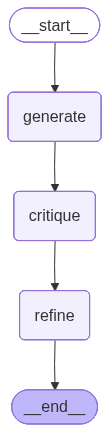

In [10]:
# Visualize the graph topology
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
# Run it
result = app.invoke({"product_name": "MeetingMind"})

print("=== Draft ===")
print(result["draft"])
print("\n=== Critique ===")
print(result["critique"])
print("\n=== Final Copy ===")
print(result["final_copy"])

=== Draft ===
# MeetingMind: Never Lose a Meeting Moment Again

Imagine walking out of every meeting with a crystal-clear record of everything that mattered — without typing a single note. **MeetingMind** is your intelligent meeting companion that joins your video calls automatically, listens with precision, and transforms hours of conversation into sharp, actionable insights. Whether you're navigating a high-stakes client presentation or a fast-moving team standup, MeetingMind captures every decision, idea, and commitment so you can stay fully present in the conversation instead of racing to keep up with it.

What sets MeetingMind apart is its ability to *understand*, not just transcribe. Using advanced contextual AI, it identifies who owns what, flags deadlines, and surfaces action items the moment they're spoken — even when no one explicitly says "action item." It learns the rhythms of your team, recognizes recurring topics, and prioritizes what's genuinely important versus what's b